In [362]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
# 1. Data Preparation
df = pd.read_csv('wine.csv')

# Quality > 5 is GOOD (1), else 0
df['target'] = (df['quality'] > 5).astype(int)

corr_matrix = df.corr()

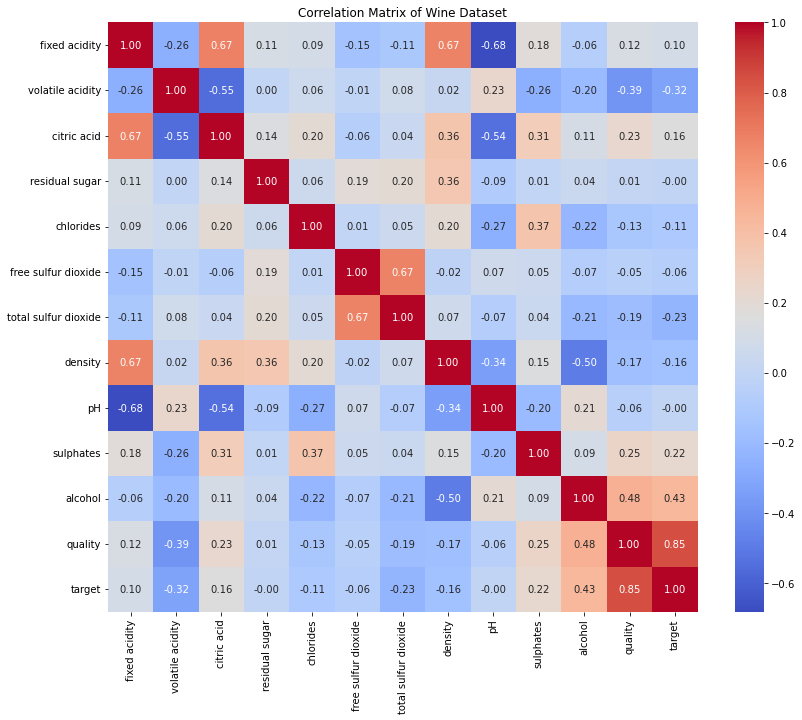

In [364]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    cbar=True
)
plt.title("Correlation Matrix of Wine Dataset")
plt.tight_layout()
plt.show()

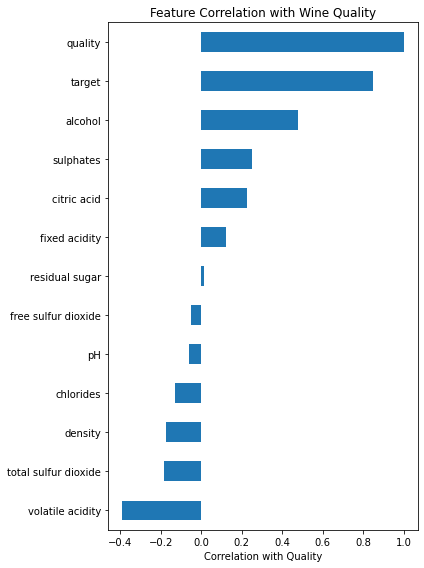

In [365]:
quality_corr = corr_matrix["quality"].sort_values(ascending=False)

plt.figure(figsize=(6, 8))
quality_corr.plot(kind="barh")
plt.xlabel("Correlation with Quality")
plt.title("Feature Correlation with Wine Quality")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [366]:

# Feature Selection (dropping same columns as your linear snippet)
X = df.drop(columns=['residual sugar']).values
y = df['target'].values

In [367]:
# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# 2. Custom Scaling (Standardization)
X_mean = np.mean(X_train, axis=0)
X_std = np.std(X_train, axis=0)
X_std[X_std == 0] = 1.0  # Prevent division by zero
X_train_scaled = (X_train - X_mean) / X_std
X_test_scaled = (X_test - X_mean) / X_std

In [368]:
class LogisticRegressionGD:
    def __init__(self, learning_rate=0.1, n_iterations=400):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for i in range(self.n_iterations):
            linear_model = np.dot(X, self.weights) + self.bias
            y_hat = self.sigmoid(linear_model)
            error = y_hat - y
            dw = (1 / n_samples) * np.dot(X.T, error)
            db = (1 / n_samples) * np.sum(error)
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
            loss = -np.mean(y * np.log(y_hat + 1e-9) + (1 - y) * np.log(1 - y_hat + 1e-9))
            self.loss_history.append(loss)

    def predict_prob(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        return self.sigmoid(linear_model)

    def predict(self, X, threshold=0.5):
        return (self.predict_prob(X) >= threshold).astype(int)


In [369]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [370]:
# 4. Model Training
model = LogisticRegressionGD(learning_rate=0.1, n_iterations=5000)
model.fit(X_train_scaled, y_train)


In [371]:
# 5. Performance Evaluation
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

print("--- Logistic Regression Results ---")
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy :", accuracy_score(y_test, y_test_pred))
print("\nConfusion Matrix (Test):\n", confusion_matrix(y_test, y_test_pred))

--- Logistic Regression Results ---
Train Accuracy: 1.0
Test Accuracy : 1.0

Confusion Matrix (Test):
 [[132   0]
 [  0 188]]


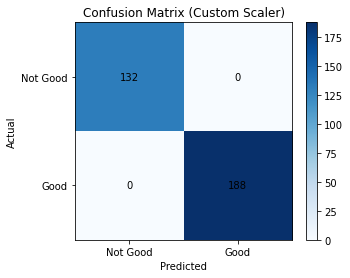

In [372]:
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap='Blues', interpolation='nearest')
plt.title('Confusion Matrix (Custom Scaler)')
plt.colorbar()
plt.xticks([0, 1], ['Not Good', 'Good'])
plt.yticks([0, 1], ['Not Good', 'Good'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
# Add numbers inside
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black')
plt.show()